In [1]:
import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-11-03/ikea.csv"

In [3]:
def create_file(file_name):
    """
    Перевіряє чи є вже файл,якщо ні, то закачує и створює csv

    :param file_name: ім'я файлу
    :return: створює csv файл
    """
    if os.path.exists((file_name)):
        print("файл існує, можемо працювати")
    else:
        print("файлу немає, починаю завантаження")
        
        response = requests.get(url)
        if requests.get(url).status_code == 200:
            with open(file_name, 'w', encoding='utf-8') as file:
                file.write(response.text)
        else:
            print("Помилка завантаження")
        
create_file("ikea.csv")   

файл існує, можемо працювати


In [4]:
def read_file(filename):
    """
    Зчитує csv файл та прибирає дублікати

    :param file_name: передаєсо файл для зчитування
    :return: повертає очищенний датафрейм
    """
    DataFrame = pd.read_csv(filename)
    DataFrame_clean = DataFrame.drop_duplicates()
    return DataFrame_clean

df = read_file("ikea.csv")
df

,Unnamed: 0,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3689,3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,NaN,91.0
3690,3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,NaN,135.0
3691,3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,NaN,175.0
3692,3692,89157573,ELVARLI,Wardrobes,2745.0,"SR 3,130",True,https://www.ikea.com/sa/en/p/elvarli-3-section...,No,"3 sections, 178x51x222-350 cm",Ehlén Johansson,50.0,NaN,178.0


# Частина перша

In [5]:
df = df.drop(columns=['Unnamed: 0']) #дубль індексу видаляємо

In [6]:
df

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,NaN,91.0
3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,NaN,135.0
3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,NaN,175.0
3692,89157573,ELVARLI,Wardrobes,2745.0,"SR 3,130",True,https://www.ikea.com/sa/en/p/elvarli-3-section...,No,"3 sections, 178x51x222-350 cm",Ehlén Johansson,50.0,NaN,178.0


In [7]:
df.duplicated(subset=['item_id']).sum()

np.int64(732)

In [8]:
df = df.drop_duplicates(subset=['item_id']).copy()
df

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,No old price,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",IKEA of Sweden/Ehlén Johansson,66.0,236.0,200.0
3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,NaN,91.0
3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,NaN,135.0
3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,NaN,175.0


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 2962 entries, 0 to 3692
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            2962 non-null   int64  
 1   name               2962 non-null   str    
 2   category           2962 non-null   str    
 3   price              2962 non-null   float64
 4   old_price          2962 non-null   str    
 5   sellable_online    2962 non-null   bool   
 6   link               2962 non-null   str    
 7   other_colors       2962 non-null   str    
 8   short_description  2962 non-null   str    
 9   designer           2962 non-null   str    
 10  depth              1844 non-null   float64
 11  height             2236 non-null   float64
 12  width              2520 non-null   float64
dtypes: bool(1), float64(4), int64(1), str(7)
memory usage: 303.7 KB


In [10]:
df.describe()

,item_id,price,depth,height,width
count,2.962000e+03,2962.000000,1844.000000,2236.000000,2520.000000
mean,4.877244e+07,1108.722552,55.920824,105.325581,109.268254
std,2.896535e+07,1393.576103,31.015201,63.166967,73.464503
min,5.848700e+04,3.000000,1.000000,1.000000,1.000000
25%,2.039630e+07,200.000000,38.000000,70.000000,60.000000
50%,4.928075e+07,570.000000,47.000000,84.000000,80.000000
75%,7.042306e+07,1475.000000,62.000000,136.000000,150.000000
max,9.993262e+07,9585.000000,257.000000,700.000000,420.000000


In [11]:
df.isna().sum()

item_id                 0
name                    0
category                0
price                   0
old_price               0
sellable_online         0
link                    0
other_colors            0
short_description       0
designer                0
depth                1118
height                726
width                 442
dtype: int64

In [12]:
df['designer'].str.contains(r'^\d', na=False).sum()

np.int64(102)

In [13]:
df[df['designer'].str.contains(r'^\d', na=False)]

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
51,50468953,VATTVIKEN,Beds,995.0,No old price,True,https://www.ikea.com/sa/en/p/vattviken-armchai...,No,Armchair-bed,504.689.53 Small and easy-to-place chair-bed w...,83.0,86.0,92.0
77,90331091,RIDABU,Beds,100.0,SR 125,True,https://www.ikea.com/sa/en/p/ridabu-mirror-doo...,No,"Mirror door, 40x120 cm",903.310.91 The door can be hung with the openi...,NaN,120.0,40.0
104,44361010,BRYNE,Beds,49.0,No old price,True,https://www.ikea.com/sa/en/p/bryne-net-white-4...,No,Net,443.610.10 Easy to keep clean since you can re...,NaN,NaN,NaN
122,70284203,ASKEBY,Beds,995.0,No old price,True,https://www.ikea.com/sa/en/p/askeby-two-seat-s...,No,Two-seat sofa-bed,"702.842.03 A sofa-bed with small, neat dimensi...",72.0,72.0,149.0
132,90299449,TUFFING,Beds,645.0,No old price,True,https://www.ikea.com/sa/en/p/tuffing-loft-bed-...,No,"Loft bed frame, 90x200 cm",902.994.49 A good solution where space is limi...,NaN,179.0,97.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2827,20400276,TRULSTORP,Tables & desks,645.0,No old price,True,https://www.ikea.com/sa/en/p/trulstorp-coffee-...,No,"Coffee table, 115x70 cm",204.002.76 One half of the table top can be ra...,NaN,40.0,70.0
2980,40426275,SKOGSTORP,Tables & desks,1795.0,No old price,True,https://www.ikea.com/sa/en/p/skogstorp-dining-...,No,"Dining table, 155x75 cm",404.262.75 Solid wood is a hardwearing natural...,75.0,78.0,155.0
3299,90295253,MOSTORP,TV & media furniture,1395.0,No old price,True,https://www.ikea.com/sa/en/p/mostorp-tv-bench-...,Yes,"TV bench, 160x47x60 cm",902.952.53 Cable outlets make it easy to lead ...,47.0,60.0,160.0
3342,10294511,BESTÅ,TV & media furniture,375.0,No old price,True,https://www.ikea.com/sa/en/p/besta-tv-bench-gr...,Yes,"TV bench, 120x40x38 cm",102.945.11 It’s easy to keep the cables from y...,40.0,38.0,120.0


In [14]:
df['designer_new'] = df['designer'].str.replace(r'^\d.*', 'Unknown', regex=True)

In [15]:
df['designer'] = df['designer_new']
df = df.drop(columns=['designer_new'])
df

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,NaN,99.0,51.0
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,NaN,105.0,80.0
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,NaN,NaN,NaN
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,No old price,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",IKEA of Sweden/Ehlén Johansson,66.0,236.0,200.0
3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,NaN,91.0
3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,NaN,135.0
3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,NaN,175.0


In [16]:
# сортируємо дизайнерів в однаковому порядку
def normalize_designers(string):
    if pd.isna(string):
        return string
    names = [name.strip() for name in string.split('/')]
    names_sorted = sorted(names)
    return '/'.join(names_sorted)

df['designer'] = df['designer'].apply(normalize_designers)

Колонка дизайнерів була неоднорідна. Імена повторювалися в різних варіаціях. Функція вище упорядкувала дані.

In [17]:
df[['depth','height','width']].agg(['mean','median','skew'])

,depth,height,width
mean,55.920824,105.325581,109.268254
median,47.000000,84.000000,80.000000
skew,2.278533,1.168393,1.310670


In [18]:
df['depth'] = df['depth'].fillna(df['depth'].median())
df['height'] = df['height'].fillna(df['height'].median())
df['width'] = df['width'].fillna(df['width'].median())

Пропуски в колонках depth, height і width були замінені медіаною.

In [19]:
df.isna().sum()

item_id              0
name                 0
category             0
price                0
old_price            0
sellable_online      0
link                 0
other_colors         0
short_description    0
designer             0
depth                0
height               0
width                0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 2962 entries, 0 to 3692
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   item_id            2962 non-null   int64  
 1   name               2962 non-null   str    
 2   category           2962 non-null   str    
 3   price              2962 non-null   float64
 4   old_price          2962 non-null   str    
 5   sellable_online    2962 non-null   bool   
 6   link               2962 non-null   str    
 7   other_colors       2962 non-null   str    
 8   short_description  2962 non-null   str    
 9   designer           2962 non-null   str    
 10  depth              2962 non-null   float64
 11  height             2962 non-null   float64
 12  width              2962 non-null   float64
dtypes: bool(1), float64(4), int64(1), str(7)
memory usage: 303.7 KB


In [21]:
df.dtypes

item_id                int64
name                     str
category                 str
price                float64
old_price                str
sellable_online         bool
link                     str
other_colors             str
short_description        str
designer                 str
depth                float64
height               float64
width                float64
dtype: object

In [22]:
df['old_price'].unique()

<StringArray>
['No old price',     'SR 2,375',       'SR 295',       'SR 175',
       'SR 995',     'SR 1,385',       'SR 445',       'SR 925',
     'SR 2,205',       'SR 895',
 ...
     'SR 2,750',     'SR 2,235',     'SR 4,510',     'SR 2,160',
     'SR 3,290',     'SR 1,460',     'SR 1,815',       'SR 820',
     'SR 1,755',     'SR 1,050']
Length: 365, dtype: str

In [23]:
df['had_discount'] = df['old_price'] != 'No old price'

In [24]:
df

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width,had_discount
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,47.0,99.0,51.0,False
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,47.0,105.0,80.0,False
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,47.0,84.0,80.0,False
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0,False
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,No old price,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",Ehlén Johansson/IKEA of Sweden,66.0,236.0,200.0,False
3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,84.0,91.0,True
3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,84.0,135.0,True
3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,84.0,175.0,True


In [25]:
def discount(string):
    if string == 'No old price':
        return np.nan
    try:
        return float(string[3:].replace(",", ""))
    except ValueError:
        return np.nan

df['old_price_new'] = df['old_price'].apply(discount)
df

,item_id,name,category,price,old_price,sellable_online,link,other_colors,short_description,designer,depth,height,width,had_discount,old_price_new
0,90420332,FREKVENS,Bar furniture,265.0,No old price,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,47.0,99.0,51.0,False,NaN
1,368814,NORDVIKEN,Bar furniture,995.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,47.0,105.0,80.0,False,NaN
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,No old price,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,47.0,84.0,80.0,False,NaN
3,80155205,STIG,Bar furniture,69.0,No old price,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0,False,NaN
4,30180504,NORBERG,Bar furniture,225.0,No old price,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,No old price,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",Ehlén Johansson/IKEA of Sweden,66.0,236.0,200.0,False,NaN
3689,99157902,ELVARLI,Wardrobes,750.0,SR 820,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,84.0,91.0,True,820.0
3690,9158152,ELVARLI,Wardrobes,1572.0,"SR 1,755",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,84.0,135.0,True,1755.0
3691,59157541,ELVARLI,Wardrobes,924.0,"SR 1,050",True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,84.0,175.0,True,1050.0


In [26]:
df = df.drop(columns=['old_price']) #цю колонку дропаю, так як було створено 2 додакові колонки на ціну

# Частина друга

#кількість товарів по категоріям

In [27]:
df_1 = df.groupby('category')['item_id'].count().sort_values(ascending=False)
df_1

category
Bookcases & shelving units              548
Chairs                                  438
Sofas & armchairs                       380
Tables & desks                          370
Wardrobes                               220
Beds                                    208
Outdoor furniture                       197
Cabinets & cupboards                    187
Chests of drawers & drawer units        111
TV & media furniture                     89
Children's furniture                     84
Bar furniture                            47
Trolleys                                 23
Nursery furniture                        22
Café furniture                           18
Sideboards, buffets & console tables     10
Room dividers                            10
Name: item_id, dtype: int64

[Text(0, 0, '548'),
 Text(0, 0, '438'),
 Text(0, 0, '380'),
 Text(0, 0, '370'),
 Text(0, 0, '220'),
 Text(0, 0, '208'),
 Text(0, 0, '197'),
 Text(0, 0, '187'),
 Text(0, 0, '111'),
 Text(0, 0, '89'),
 Text(0, 0, '84'),
 Text(0, 0, '47'),
 Text(0, 0, '23'),
 Text(0, 0, '22'),
 Text(0, 0, '18'),
 Text(0, 0, '10'),
 Text(0, 0, '10')]

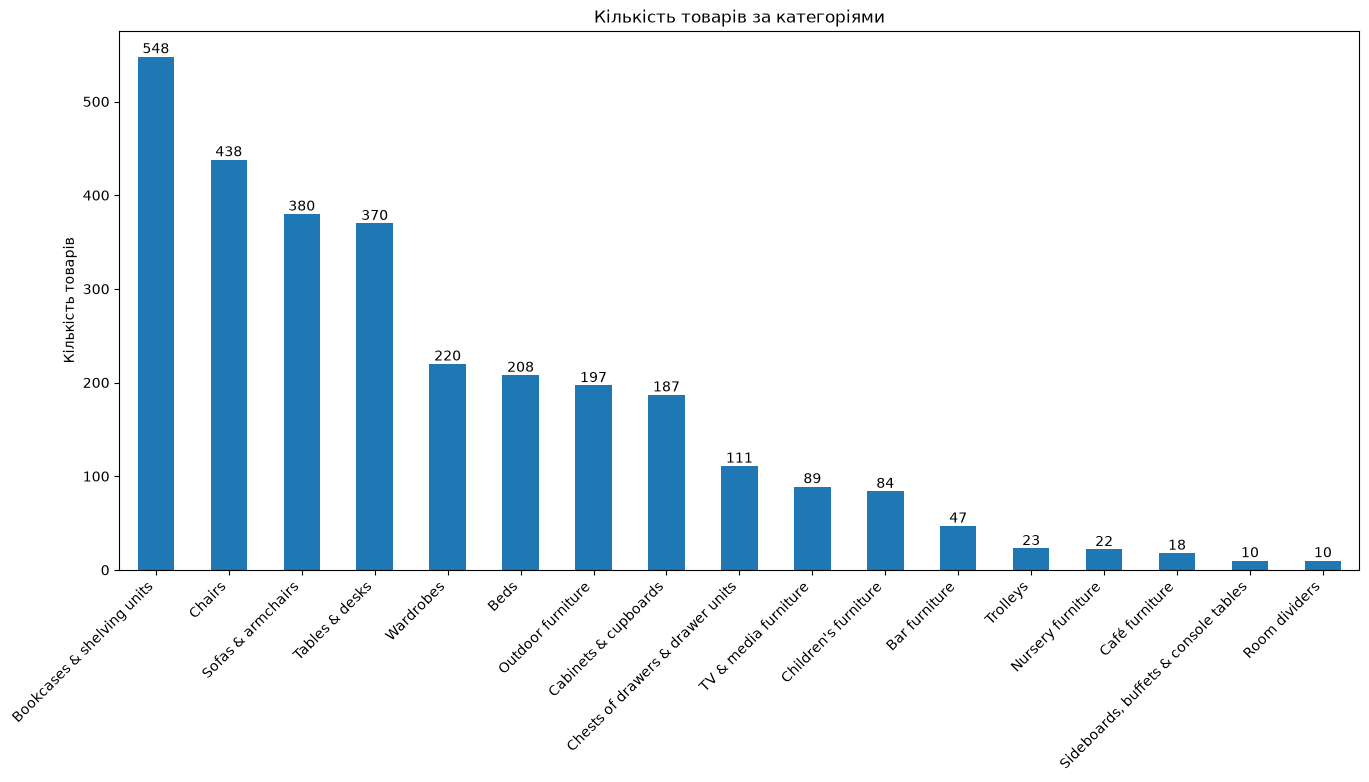

In [28]:
plt.figure(figsize=(16,7))
ax = df_1.plot.bar()
plt.xticks(rotation=45, ha='right')

plt.title('Кількість товарів за категоріями')
plt.ylabel('Кількість товарів')
plt.xlabel('')
ax.bar_label(ax.containers[0])

In [29]:
df_2 = df.groupby('category')['price'].median().sort_values(ascending=False)
df_2

category
Wardrobes                               1950.0
Sofas & armchairs                       1157.0
Beds                                    1093.5
Sideboards, buffets & console tables     927.5
TV & media furniture                     860.0
Cabinets & cupboards                     845.0
Room dividers                            595.0
Trolleys                                 537.0
Chests of drawers & drawer units         499.0
Chairs                                   497.0
Tables & desks                           475.0
Bar furniture                            445.0
Café furniture                           370.0
Outdoor furniture                        345.0
Nursery furniture                        322.5
Bookcases & shelving units               310.0
Children's furniture                     202.5
Name: price, dtype: float64

[Text(0, 0, '1950'),
 Text(0, 0, '1157'),
 Text(0, 0, '1093.5'),
 Text(0, 0, '927.5'),
 Text(0, 0, '860'),
 Text(0, 0, '845'),
 Text(0, 0, '595'),
 Text(0, 0, '537'),
 Text(0, 0, '499'),
 Text(0, 0, '497'),
 Text(0, 0, '475'),
 Text(0, 0, '445'),
 Text(0, 0, '370'),
 Text(0, 0, '345'),
 Text(0, 0, '322.5'),
 Text(0, 0, '310'),
 Text(0, 0, '202.5')]

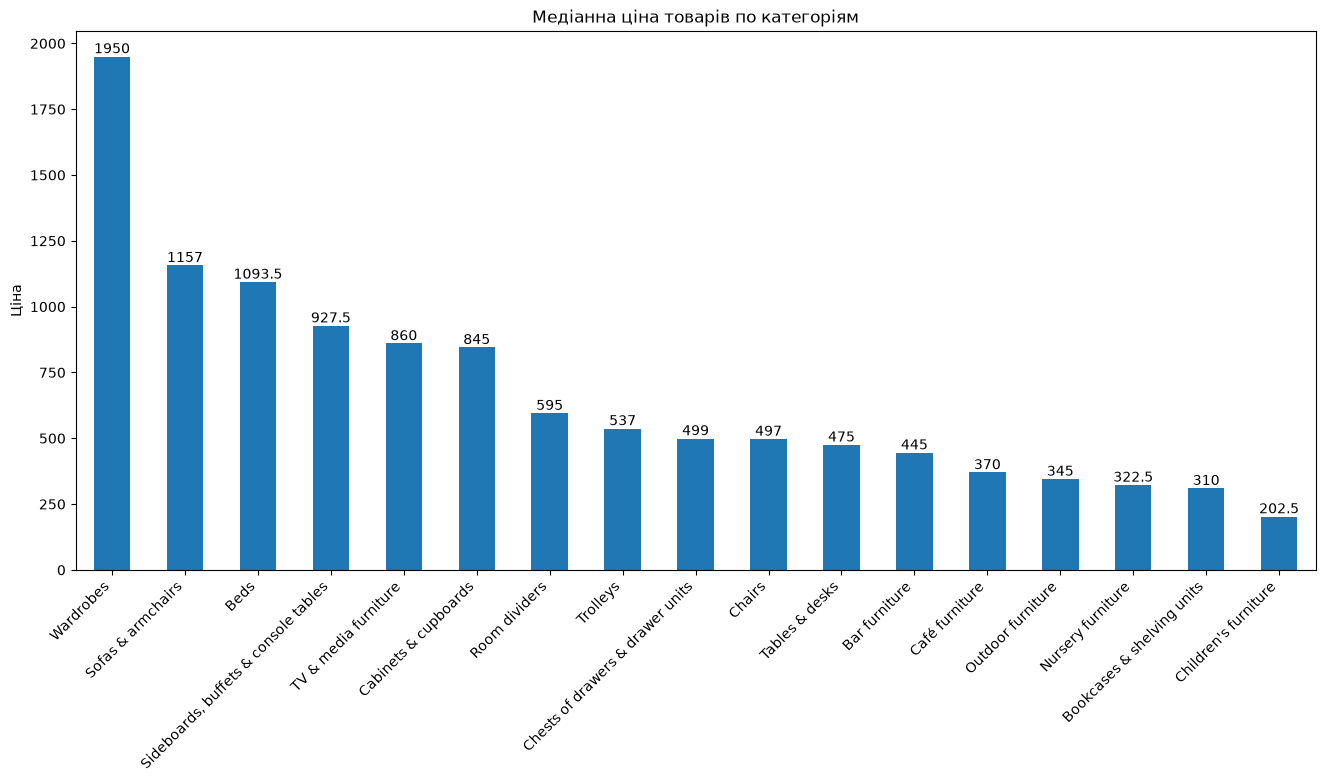

In [30]:
plt.figure(figsize=(16,7))
ax = df_2.plot.bar()
plt.xticks(rotation=45, ha='right')

plt.title('Медіанна ціна товарів по категоріям')
plt.ylabel('Ціна')
plt.xlabel('')
ax.bar_label(ax.containers[0])

In [31]:
# Вардробс найдорожчі, хоча основу товару явдяє Bookcases & shelving units

In [32]:
df_3 = df[['price', 'depth', 'height', 'width']].corr(method="spearman")
df_3

,price,depth,height,width
price,1.000000,0.346016,0.383988,0.685649
depth,0.346016,1.000000,0.058321,0.208843
height,0.383988,0.058321,1.000000,0.363980
width,0.685649,0.208843,0.363980,1.000000


(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0.5, 0, 'price'),
  Text(1.5, 0, 'depth'),
  Text(2.5, 0, 'height'),
  Text(3.5, 0, 'width')])

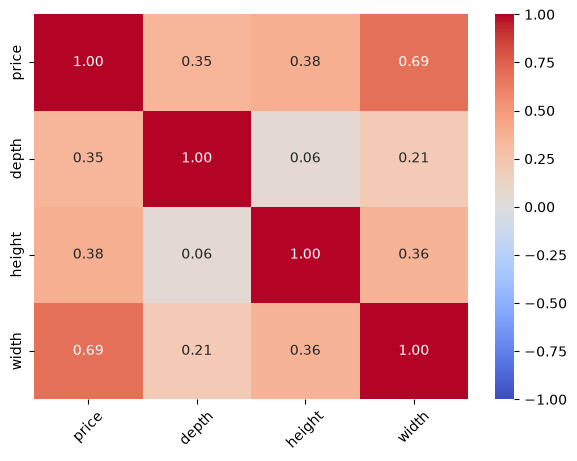

In [33]:
plt.figure(figsize=(7,5))
sns.heatmap(df_3, annot=True, fmt=".2f",vmin=-1., cmap="coolwarm")
plt.xticks(rotation=45)

In [34]:
df_4 = df.groupby('designer')['item_id'].count().sort_values(ascending=False)
df_4 = df_4[df_4.index != 'Unknown']
df_4 = df_4[:15]

[Text(0, 0, '683'),
 Text(0, 0, '138'),
 Text(0, 0, '136'),
 Text(0, 0, '131'),
 Text(0, 0, '128'),
 Text(0, 0, '106'),
 Text(0, 0, '98'),
 Text(0, 0, '64'),
 Text(0, 0, '60'),
 Text(0, 0, '55'),
 Text(0, 0, '46'),
 Text(0, 0, '43'),
 Text(0, 0, '42'),
 Text(0, 0, '41'),
 Text(0, 0, '35')]

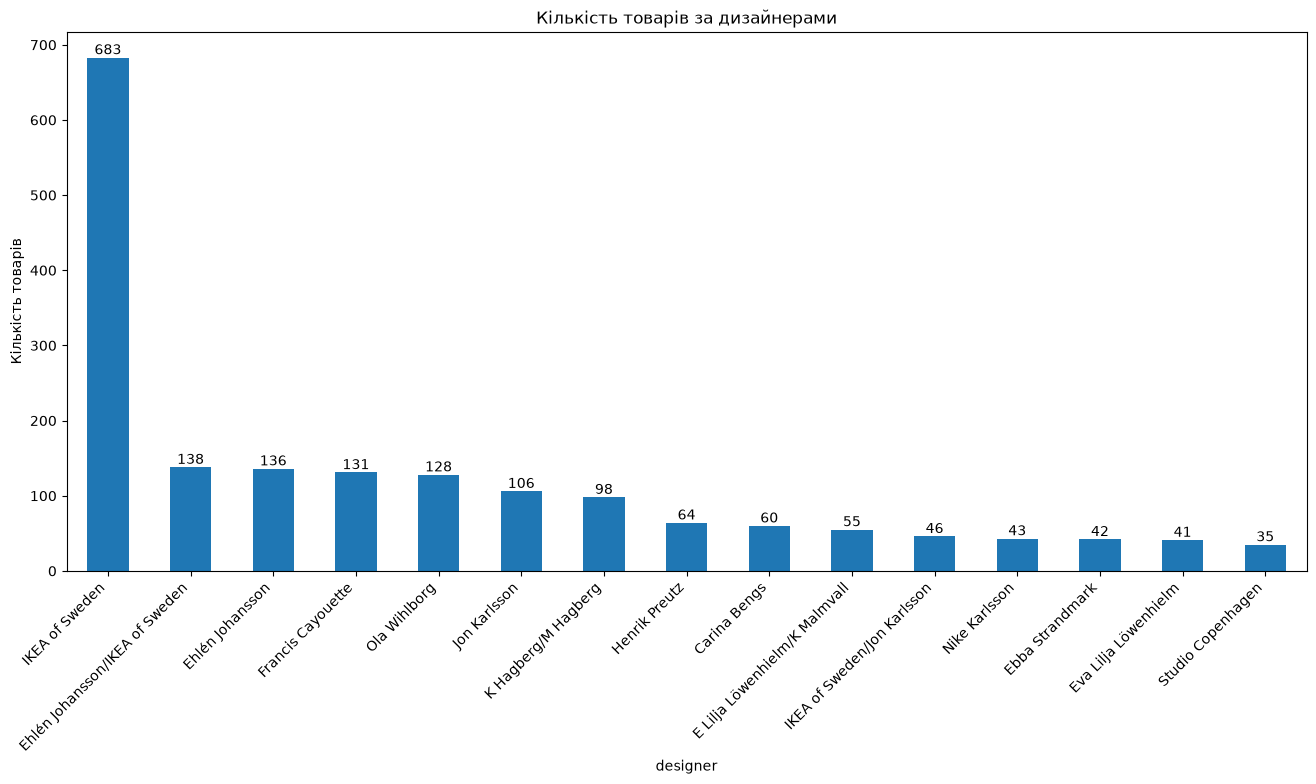

In [35]:
plt.figure(figsize=(16,7))
ax = df_4.plot.bar()
plt.xticks(rotation=45, ha='right')
plt.title('Кількість товарів за дизайнерами')
plt.ylabel('Кількість товарів')

ax.bar_label(ax.containers[0])

In [36]:
df_5 = df.groupby('designer')['price'].median().sort_values(ascending=False)
df_5 = df_5[df_5.index != 'Unknown']
df_5 = df_5[:15]

In [37]:
df_5

designer
Ehlén Johansson/Fredriksson/Hilland/L Löwenhielm                   7988.0
Ebba Strandmark/Ehlén Johansson/IKEA of Sweden/Ola Wihlborg        6065.0
Ehlén Johansson/Ola Wihlborg                                       5465.0
Carl Öjerstam/J Marnell/S Lanneskog                                5370.0
J Marnell/Ola Wihlborg/S Lanneskog                                 5275.0
Henrik Preutz/IKEA of Sweden                                       4841.0
Andreas Fredriksson/Marcus Arvonen                                 4785.0
IKEA of Sweden/J Marnell/S Lanneskog                               4745.0
Ehlén Johansson/Francis Cayouette/IKEA of Sweden                   4590.0
Ehlén Johansson/Karl Malmvall                                      4565.0
Ehlén Johansson/Fredriksson/Hilland/IKEA of Sweden/L Löwenhielm    4448.0
Chris Martin/IKEA of Sweden/Ola Wihlborg                           4295.0
J Löfgren/J Pettersson/Marcus Arvonen                              4265.0
Carl Öjerstam/IKEA of Sweden/

[Text(0, 0, '7988'),
 Text(0, 0, '6065'),
 Text(0, 0, '5465'),
 Text(0, 0, '5370'),
 Text(0, 0, '5275'),
 Text(0, 0, '4841'),
 Text(0, 0, '4785'),
 Text(0, 0, '4745'),
 Text(0, 0, '4590'),
 Text(0, 0, '4565'),
 Text(0, 0, '4448'),
 Text(0, 0, '4295'),
 Text(0, 0, '4265'),
 Text(0, 0, '3875'),
 Text(0, 0, '3870')]

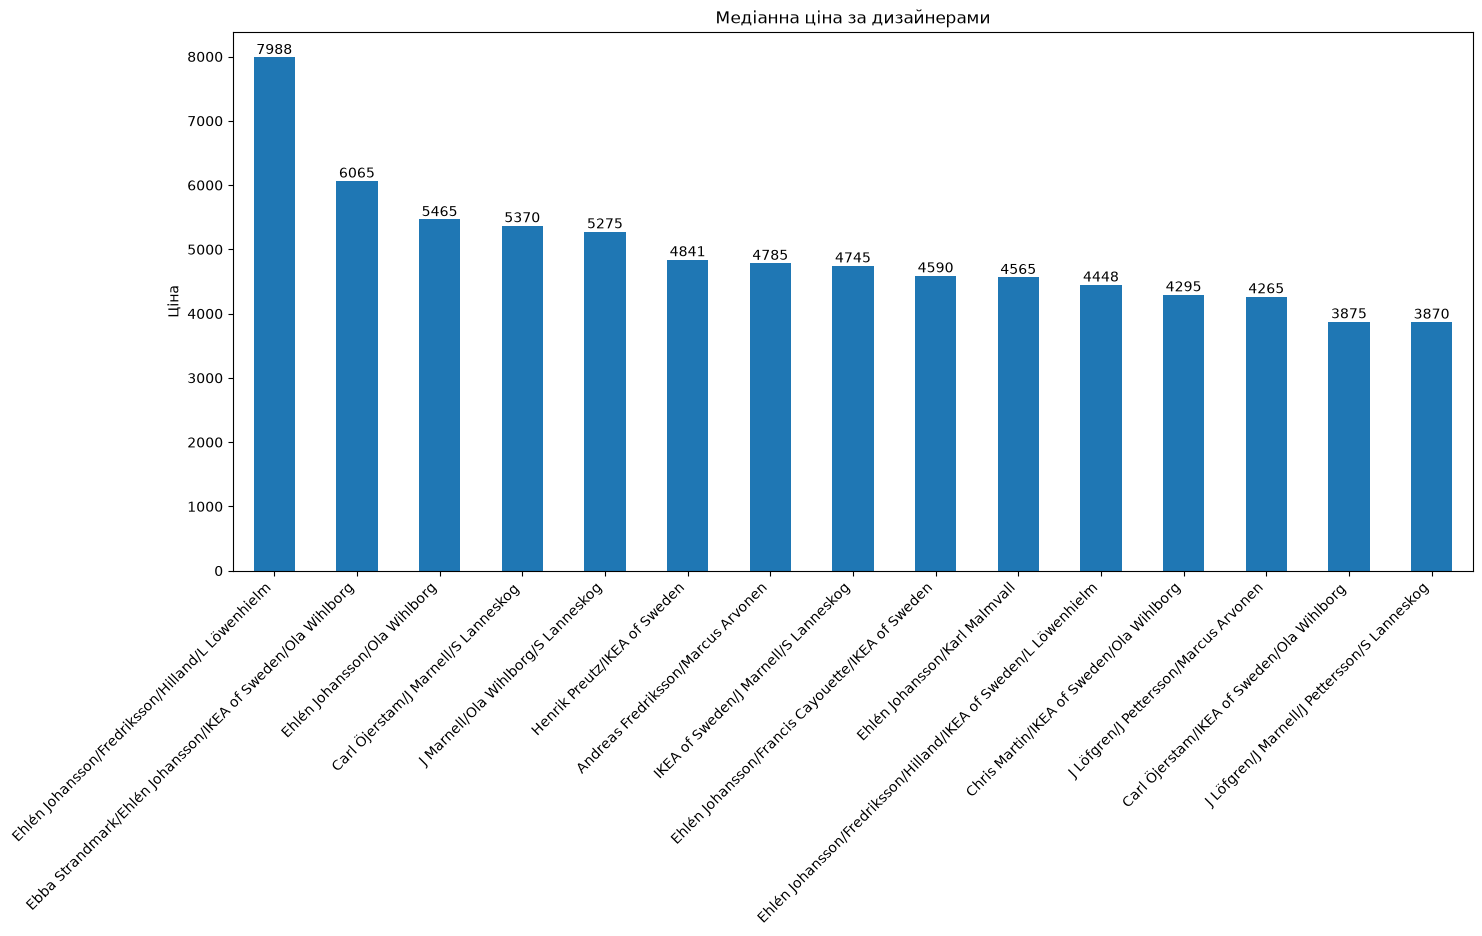

In [38]:
plt.figure(figsize=(16,7))
ax = df_5.plot.bar()
plt.xticks(rotation=45, ha='right')

plt.title('Медіанна ціна за дизайнерами')
plt.ylabel('Ціна')
plt.xlabel('')
ax.bar_label(ax.containers[0])

In [39]:
df.groupby('designer')['item_id'].count().loc[df_5.index]

designer
Ehlén Johansson/Fredriksson/Hilland/L Löwenhielm                    1
Ebba Strandmark/Ehlén Johansson/IKEA of Sweden/Ola Wihlborg         3
Ehlén Johansson/Ola Wihlborg                                        4
Carl Öjerstam/J Marnell/S Lanneskog                                 2
J Marnell/Ola Wihlborg/S Lanneskog                                  5
Henrik Preutz/IKEA of Sweden                                       13
Andreas Fredriksson/Marcus Arvonen                                  1
IKEA of Sweden/J Marnell/S Lanneskog                                3
Ehlén Johansson/Francis Cayouette/IKEA of Sweden                   12
Ehlén Johansson/Karl Malmvall                                       1
Ehlén Johansson/Fredriksson/Hilland/IKEA of Sweden/L Löwenhielm     1
Chris Martin/IKEA of Sweden/Ola Wihlborg                            2
J Löfgren/J Pettersson/Marcus Arvonen                               1
Carl Öjerstam/IKEA of Sweden/Ola Wihlborg                           1
J Löfgren/J

Топ-15 дизайнерів мають переважно один або декілька товарів. Тобто це не загальна цінова політика конкеретного дизайнера.

In [40]:
df_6 = df.groupby('other_colors')['item_id'].count().sort_values(ascending=False)
df_6

other_colors
No     1637
Yes    1325
Name: item_id, dtype: int64

[Text(0, 0, '1637'), Text(0, 0, '1325')]

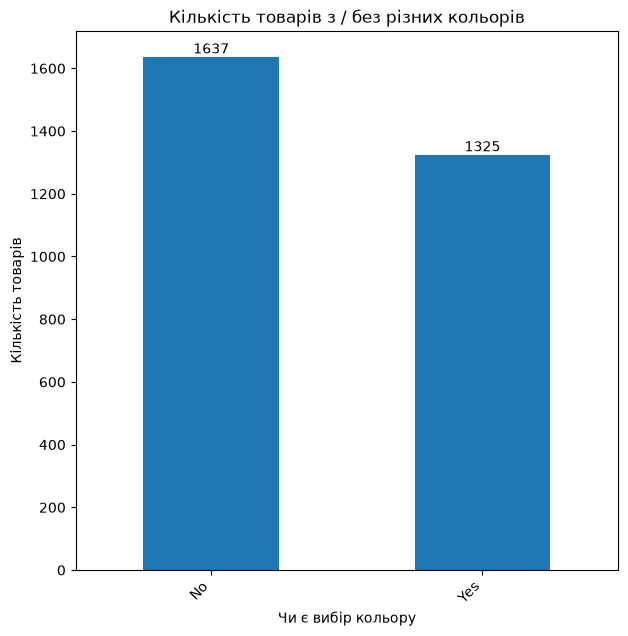

In [41]:
plt.figure(figsize=(7,7))
ax =df_6.plot.bar()
plt.xticks(rotation=45, ha='right')

plt.title('Кількість товарів з / без різних кольорів')
plt.ylabel('Кількість товарів')
plt.xlabel('Чи є вибір кольору')
ax.bar_label(ax.containers[0])

In [42]:
df_7 = df.groupby('other_colors')['price'].median().sort_values(ascending=False)
df_7

other_colors
Yes    695.0
No     476.0
Name: price, dtype: float64

[Text(0, 0, '695'), Text(0, 0, '476')]

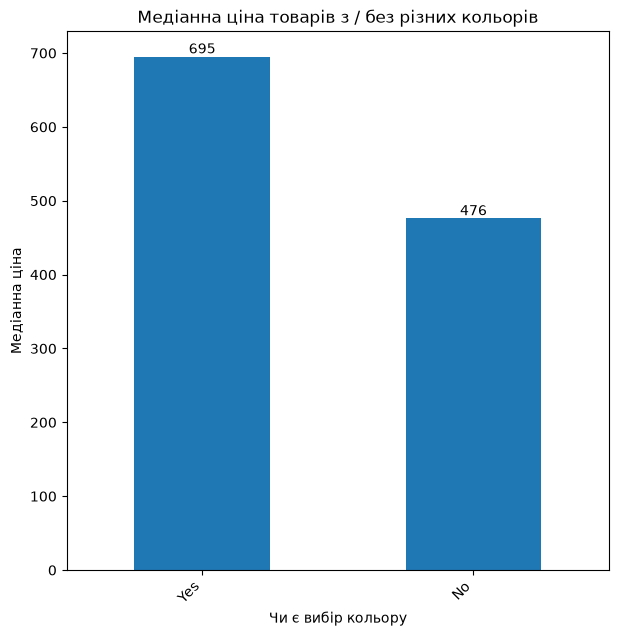

In [43]:
plt.figure(figsize=(7,7))
ax = df_7.plot.bar()
plt.xticks(rotation=45, ha='right')

plt.title('Медіанна ціна товарів з / без різних кольорів')
plt.ylabel('Медіанна ціна')
plt.xlabel('Чи є вибір кольору')
ax.bar_label(ax.containers[0])

Товари які мають вибір кольору коштують більше

In [44]:
df_8 = df.groupby('sellable_online')['item_id'].count().sort_values(ascending=False)
df_8 = df_8.rename(index={True: 'Онлайн', False: 'Не онлайн'})
df_8

sellable_online
Онлайн       2943
Не онлайн      19
Name: item_id, dtype: int64

[Text(0, 0, '2943'), Text(0, 0, '19')]

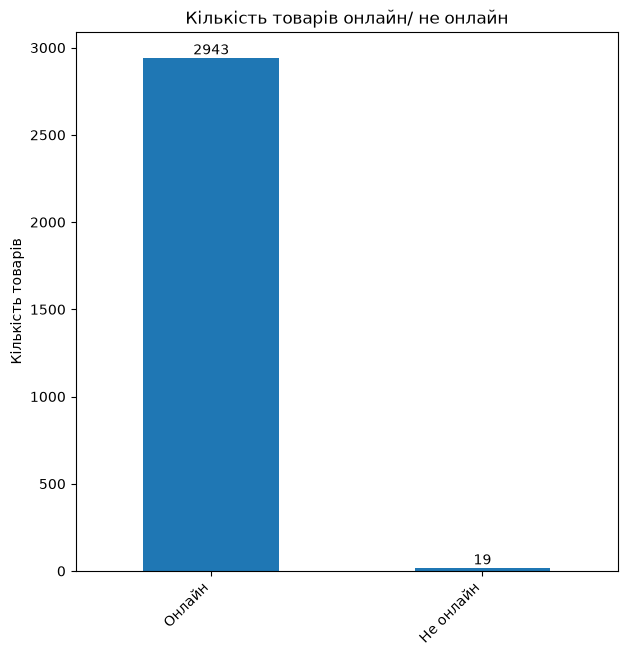

In [45]:
plt.figure(figsize=(7,7))
ax =df_8.plot.bar()
plt.xticks(rotation=45, ha='right')

plt.title('Кількість товарів онлайн/ не онлайн')
plt.ylabel('Кількість товарів')
plt.xlabel('')
ax.bar_label(ax.containers[0])

In [46]:
df_9 = df.groupby('sellable_online')['price'].median().sort_values(ascending=False)
df_9 = df_9.rename(index={True: 'Онлайн', False: 'Не онлайн'})
df_9

sellable_online
Онлайн       575.0
Не онлайн    200.0
Name: price, dtype: float64

[Text(0, 0, '575'), Text(0, 0, '200')]

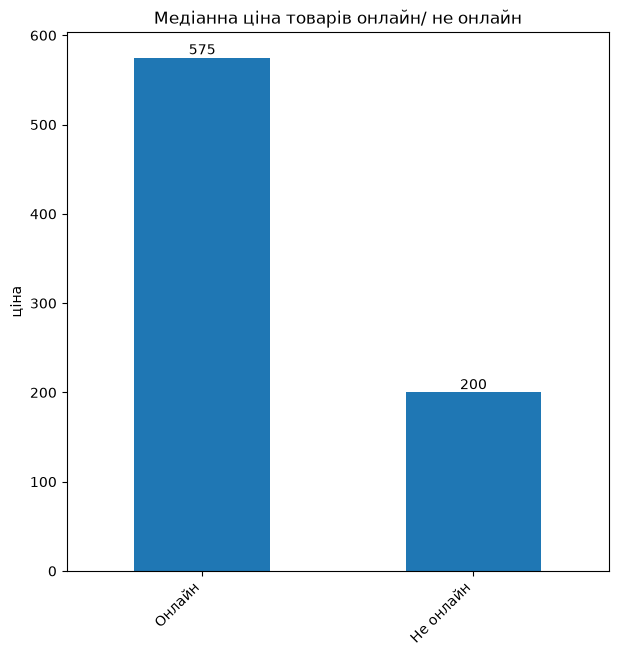

In [47]:
plt.figure(figsize=(7,7))
ax = df_9.plot.bar()
plt.xticks(rotation=45, ha='right')

plt.title('Медіанна ціна товарів онлайн/ не онлайн')
plt.ylabel('ціна')
plt.xlabel('')
ax.bar_label(ax.containers[0])

онлайн товари коштують більше, але оскільки в категорії "не онлайн" замало товару, то не це не можно вважати надійним показником

Text(0, 0.5, 'Кількість товарів')

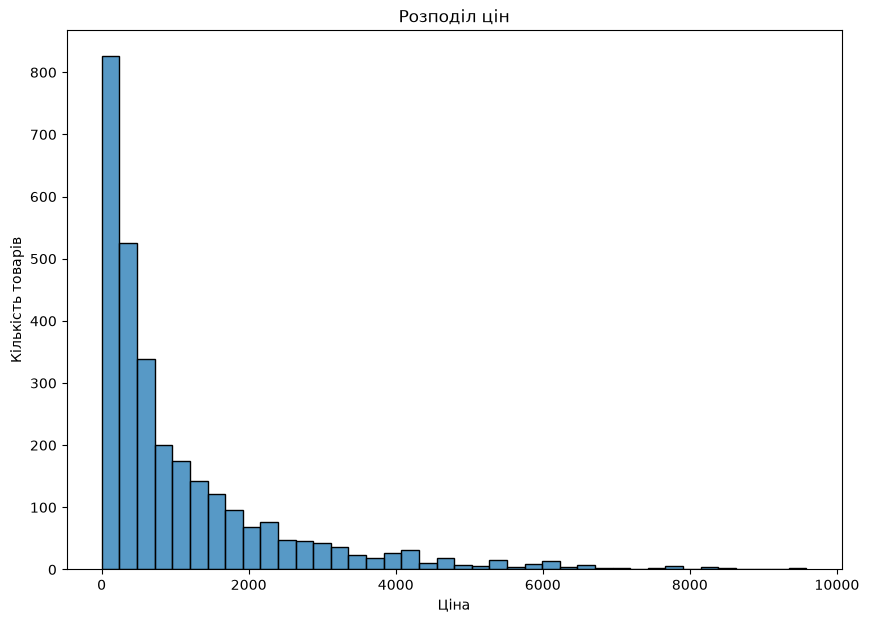

In [48]:
plt.figure(figsize=(10,7))
sns.histplot(df['price'], bins=40)
plt.title('Розподіл цін')
plt.xlabel('Ціна')
plt.ylabel('Кількість товарів')

по графіку бачимо, ща більшість товарі має ціну до 1000 SR , а потім починаеться суттєве зниження кількості товарі зі зростанням ціни

Text(0, 0.5, 'Ціна (поточна)')

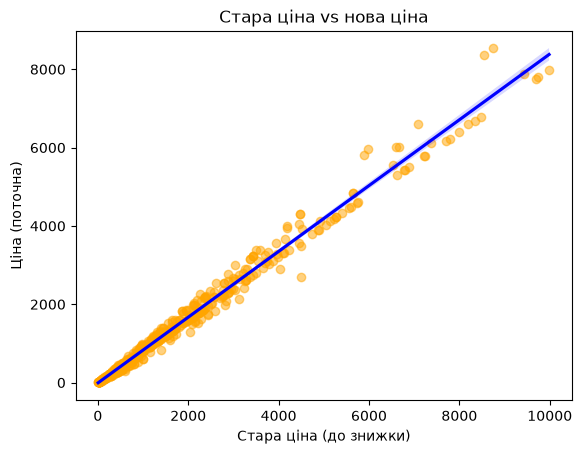

In [49]:
sns.regplot(data=df, x = 'old_price_new', y = 'price', line_kws={'color': 'blue'}, scatter_kws={'color': 'orange', 'alpha': 0.5})
plt.title('Стара ціна vs нова ціна')
plt.xlabel('Стара ціна (до знижки)')
plt.ylabel('Ціна (поточна)')

# Частина третя

Гіпотеза № 1
H₀ = Медіанна ціна з кольором чи без не відрізняється
H₁ = Медіанна ціна статистично відрізняється між товарами з вибором кольору чи без

In [50]:
group_a = df.loc[df['other_colors'] == 'Yes', 'price'].dropna()
group_b = df.loc[df['other_colors'] == 'No', 'price'].dropna()

result = mannwhitneyu(group_a, group_b)
result

MannwhitneyuResult(statistic=np.float64(1239016.5), pvalue=np.float64(2.449592606135266e-11))

По тесту "U-критерий Манна — Уитни" бачимо, що закономірність від наявності кольору є.

<Axes: xlabel='price_ln', ylabel='Count'>

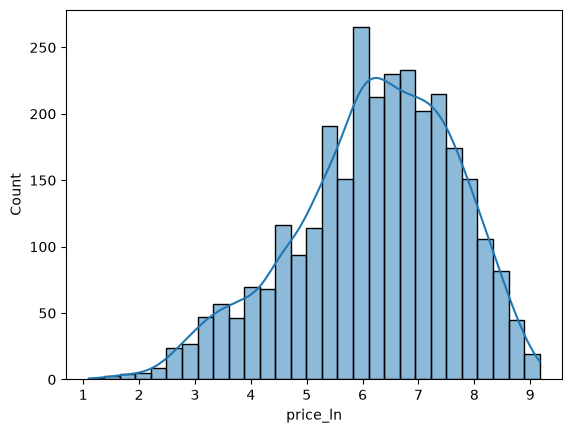

In [51]:
df['price_ln'] = np.log(df['price'])

sns.histplot(df['price_ln'], kde=True)

Графік показує, що розподіл став більш нормальним.

In [52]:
np.random.seed(12)

observed_diff = group_a.median() - group_b.median()

combined = pd.concat([group_a, group_b])
n_a = len(group_a)

n_iterations = 10000
diffs = []

for _ in range(n_iterations):
    shuffled = combined.sample(frac=1, replace=False).reset_index(drop=True)
    new_a = shuffled[:n_a]
    new_b = shuffled[n_a:]
    diffs.append(new_a.median() - new_b.median())

diffs = np.array(diffs)
p_value = (np.abs(diffs) >= np.abs(observed_diff)).mean()

print(f"Спостережувана різниця медіан: {observed_diff:.2f}")
print(f"Bootstrap p-value: {p_value:.5f}")

Спостережувана різниця медіан: 219.00
Bootstrap p-value: 0.00000


In [53]:
group_a_log = df.loc[df['other_colors'] == 'Yes', 'price_ln'].dropna()
group_b_log = df.loc[df['other_colors'] == 'No', 'price_ln'].dropna()

observed_diff_log = group_a_log.median() - group_b_log.median()

combined_log = pd.concat([group_a_log, group_b_log])
n_a_log = len(group_a_log)

diffs_log = []
for _ in range(n_iterations):
    shuffled = combined_log.sample(frac=1, replace=False).reset_index(drop=True)
    new_a = shuffled[:n_a_log]
    new_b = shuffled[n_a_log:]
    diffs_log.append(new_a.median() - new_b.median())

diffs_log = np.array(diffs_log)
p_value_log = (np.abs(diffs_log) >= np.abs(observed_diff_log)).mean()

print(f"Спостережувана різниця медіан (log): {observed_diff_log:.4f}")
print(f"Bootstrap p-value (log): {p_value_log:.5f}")

Спостережувана різниця медіан (log): 0.3785
Bootstrap p-value (log): 0.00000


Логарифмування не змінило p-value. Гіпотеза підтверджена.

Гіпотеза № 2
H₀ = Медіанна ціна однакова в усіх категоріях 
H₁ = Медіанна ціна відрізняється між категоріями

In [54]:
df_kru = df.groupby('category')['price']

groups = [group.values for name, group in df_kru]
stat, p_value = kruskal(*groups)

print(stat)
print(p_value)

548.9566440618943
1.4923903994212548e-106


In [55]:
np.random.seed(42)

kruskal_stat = stat  # дані з тесту Крускала вище

categories_mix = np.array(df['category'].values.copy())
prices = df['price'].values

n_cycles = 1000 #вирішив взять 1000, так как на 10тис дуже довго ітерувало
boot_stat = []

for _ in range(n_cycles):
    np.random.shuffle(categories_mix)
    
    df_temp = pd.DataFrame({'category': categories_mix, 'price': prices})
    groups_temp = [group['price'].values for name, group in df_temp.groupby('category')]
    
    stat_temp, _ = kruskal(*groups_temp)
    boot_stat.append(stat_temp)

boot_stat = np.array(boot_stat)
p_value_boot = (boot_stat >= kruskal_stat).mean()

print(f"Спостережувана H-статистика: {kruskal_stat:.2f}")
print(f"Bootstrap p-value: {p_value_boot:.5f}")

Спостережувана H-статистика: 548.96
Bootstrap p-value: 0.00000


Гіпотеза підтверджена, що медіанна ціна має статистичний зв'язок з категорією

# Частина четверта

Pipeline:

In [56]:
def binary_other_colors(string):
    if string == 'Yes':
        return 1
    else:
        return 0

df['other_colors_bin'] = df['other_colors'].apply(binary_other_colors)
df

,item_id,name,category,price,sellable_online,link,other_colors,short_description,designer,depth,height,width,had_discount,old_price_new,price_ln,other_colors_bin
0,90420332,FREKVENS,Bar furniture,265.0,True,https://www.ikea.com/sa/en/p/frekvens-bar-tabl...,No,"Bar table, in/outdoor, 51x51 cm",Nicholai Wiig Hansen,47.0,99.0,51.0,False,NaN,5.579730,0
1,368814,NORDVIKEN,Bar furniture,995.0,False,https://www.ikea.com/sa/en/p/nordviken-bar-tab...,No,"Bar table, 140x80 cm",Francis Cayouette,47.0,105.0,80.0,False,NaN,6.902743,0
2,9333523,NORDVIKEN / NORDVIKEN,Bar furniture,2095.0,False,https://www.ikea.com/sa/en/p/nordviken-nordvik...,No,Bar table and 4 bar stools,Francis Cayouette,47.0,84.0,80.0,False,NaN,7.647309,0
3,80155205,STIG,Bar furniture,69.0,True,https://www.ikea.com/sa/en/p/stig-bar-stool-wi...,Yes,"Bar stool with backrest, 74 cm",Henrik Preutz,50.0,100.0,60.0,False,NaN,4.234107,1
4,30180504,NORBERG,Bar furniture,225.0,True,https://www.ikea.com/sa/en/p/norberg-wall-moun...,No,"Wall-mounted drop-leaf table, ...",Marcus Arvonen,60.0,43.0,74.0,False,NaN,5.416100,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3688,89330653,PAX / MEHAMN/AULI,Wardrobes,2045.0,True,https://www.ikea.com/sa/en/p/pax-mehamn-auli-w...,No,"Wardrobe combination, 200x66x...",Ehlén Johansson/IKEA of Sweden,66.0,236.0,200.0,False,NaN,7.623153,0
3689,99157902,ELVARLI,Wardrobes,750.0,True,https://www.ikea.com/sa/en/p/elvarli-1-section...,No,"1 section, 92x51x222-350 cm",Ehlén Johansson,50.0,84.0,91.0,True,820.0,6.620073,0
3690,9158152,ELVARLI,Wardrobes,1572.0,True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 135x51x222-350 cm",Ehlén Johansson,50.0,84.0,135.0,True,1755.0,7.360104,0
3691,59157541,ELVARLI,Wardrobes,924.0,True,https://www.ikea.com/sa/en/p/elvarli-2-section...,No,"2 sections, 175x51x222-350 cm",Ehlén Johansson,50.0,84.0,175.0,True,1050.0,6.828712,0


In [57]:
X = df[['category', 'other_colors_bin', 'depth', 'height', 'width','designer']]
y = df['price']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [59]:
col_to_scale = ['depth', 'height', 'width']

encode_cat = ['category']
encode_des = ['designer']

other_colors = ['other_colors_bin']

In [60]:
preprocessor = ColumnTransformer([
    ("scale_num", StandardScaler(), col_to_scale),
    ("encode_cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), encode_cat),
    ("encode_des", OneHotEncoder(sparse_output=False, drop="if_binary", min_frequency=10 ,  handle_unknown='infrequent_if_exist'), encode_des),
    ("other_colors_bin", 'passthrough', other_colors)
],
        verbose_feature_names_out=False).set_output(transform="pandas")                         


In [61]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_train_transformed.head()

,depth,height,width,category_Bar furniture,category_Beds,category_Bookcases & shelving units,category_Cabinets & cupboards,category_Café furniture,category_Chairs,category_Chests of drawers & drawer units,...,designer_Nike Karlsson,designer_Noboru Nakamura,designer_Ola Wihlborg,designer_Studio Copenhagen,designer_Tina Christensen,designer_Tom Dixon,designer_Tord Björklund,designer_Unknown,designer_infrequent_sklearn,other_colors_bin
518,-0.710338,1.975293,1.031641,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3619,0.084368,2.082706,0.286372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
573,-0.909015,2.458650,0.227919,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1172,-0.114308,-0.065548,-0.824226,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2196,-0.630867,0.614733,0.841671,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


Дизайнери, які зустрінуться в тренуванні менше за 10 раз, попадають в додаткову групу "designer_infrequent_sklearn". Це зроблено для того щоб модель навчалась лише за тих зразків які мають більше даних.

In [62]:
imputer_step = ColumnTransformer([
    ("imputer_num", SimpleImputer(strategy="median"),col_to_scale),
    ("imputer_cat", SimpleImputer(strategy="most_frequent"),encode_cat),
    ("imputer_des", SimpleImputer(strategy="most_frequent"),encode_des),
    ("imputer_color", 'passthrough',other_colors),
    
],
      verbose_feature_names_out=False).set_output(transform="pandas")
imputer_step

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer_num', ...), ('imputer_cat', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features

In [63]:
imputer_step.fit_transform(X_train).head()

,depth,height,width,category,designer,other_colors_bin
518,35.0,210.0,175.0,Bookcases & shelving units,IKEA of Sweden/Jon Karlsson,1
3619,55.0,216.0,124.0,Wardrobes,Ehlén Johansson/IKEA of Sweden,0
573,30.0,237.0,120.0,Bookcases & shelving units,Gillis Lundgren/IKEA of Sweden/K Hagberg/M Hag...,1
1172,50.0,96.0,48.0,Chairs,IKEA of Sweden,0
2196,37.0,134.0,162.0,"Sideboards, buffets & console tables",IKEA of Sweden,1


In [64]:
full_pipeline = Pipeline([
    ("imputer", imputer_step),
    ("FE", preprocessor),
    ("model", LinearRegression())
])
full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('FE', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer_num', ...), ('imputer_cat', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

In [65]:
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

In [66]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.4f}")

RMSE: 872.16
R^2: 0.5961


In [67]:
list_of_models = [LinearRegression(),
                  RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs= -1 ),
                  GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42 )
                 ]

results = []

for model in list_of_models:
    pipe = Pipeline([
    ("imputer", imputer_step),
    ("FE", preprocessor),
    ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({'Model': type(model).__name__ ,'RMSE': rmse, 'R2': r2})

In [68]:
models_result = pd.DataFrame(results)
models_result

,Model,RMSE,R2
0,LinearRegression,872.161912,0.596143
1,RandomForestRegressor,630.996032,0.788609
2,GradientBoostingRegressor,641.097763,0.781786


[Text(0, 0, '0.5961'), Text(0, 0, '0.7886'), Text(0, 0, '0.7818')]

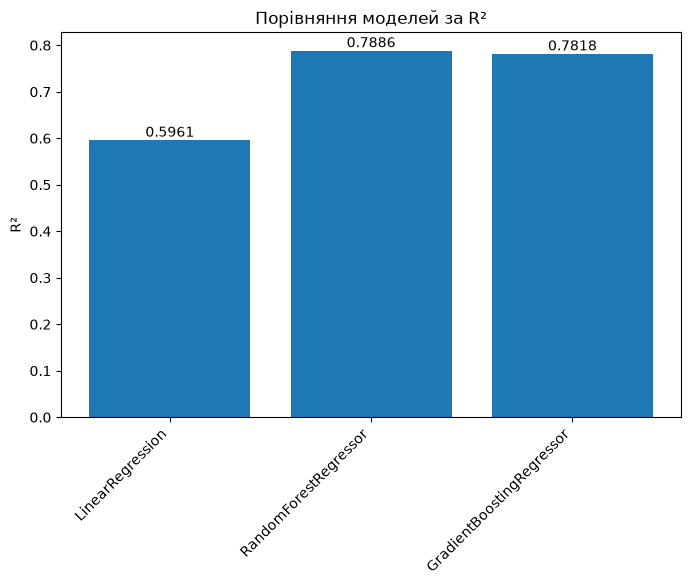

In [69]:
plt.figure(figsize=(8,5))
ax = plt.bar(models_result['Model'], models_result['R2'])

plt.title('Порівняння моделей за R²')
plt.ylabel('R²')
plt.xticks(rotation=45, ha='right')
plt.bar_label(ax , fmt='%.4f')

RandomForest на 78% успішно пояснює розкид цін. Середня помилка прогнозу становить 631 SR.

===================

GridSearchCV:

In [70]:
param_grid = {
    "model__n_estimators": [80, 120, 160, 200],
    "model__max_depth": np.arange(5, 15),
    "model__max_features": ["sqrt", None]
}

In [71]:
rf_pipeline = Pipeline([
    ("imputer", imputer_step),
    ("FE", preprocessor),
    ("model", RandomForestRegressor(random_state = 42))
])
rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('FE', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer_num', ...), ('imputer_cat', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g.

In [72]:
grid_search = GridSearchCV(estimator=rf_pipeline, param_grid=param_grid, scoring="r2", cv=5 )
grid_search.fit(X_train, y_train)
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': array([ 5, 6..., 12, 13, 14]), 'model__max_features': ['sqrt', None], 'model__n_estimators': [80, 120, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True


In [73]:
y_pred_best = grid_search.best_estimator_.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print(f"RMSE: {rmse_best:.2f}")
print(f"R^2: {r2_best:.4f}")

RMSE: 610.68
R^2: 0.8020


In [74]:
grid_search.best_params_

{'model__max_depth': np.int64(14),
 'model__max_features': None,
 'model__n_estimators': 200}

In [75]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('FE', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['category','other_colors_bin','depth','height','width','designer']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer_num', ...), ('imputer_cat', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any fe

In [76]:
grid_search.best_score_

np.float64(0.7767740296814707)

Перші параметри були задані трохи меншими і найкращі знайдені значення впиралися у верхню межу заданих чисел. Було вирішено збільшити параметри дерев та глибини. Це займає більше часу, але результат покращився, хоча знов уперся в стелю. Далі, було вирішено зупинитися збільшувати параметри, так як покращення моделі вже відбулося.

================

Feature Importance:

In [77]:
best_model = grid_search.best_estimator_

importances = best_model.named_steps["model"].feature_importances_
feature_names = best_model.named_steps["FE"].get_feature_names_out()

importance_df = pd.DataFrame({ 'Feature': feature_names, 'Importance': importances})

importance_df

,Feature,Importance
0,depth,0.139038
1,height,0.073311
2,width,0.610153
3,category_Bar furniture,0.001697
4,category_Beds,0.006551
...,...,...
56,designer_Tom Dixon,0.000879
57,designer_Tord Björklund,0.000190
58,designer_Unknown,0.001079
59,designer_infrequent_sklearn,0.023937


In [78]:
def get_base_feature(name):
    if name.startswith('category'):
        return 'category'
    elif name.startswith('other_colors'):
        return 'other_colors'
    elif name.startswith('designer'):
        return 'designer'
    else:
        return name

importance_df['Base_Feature'] = importance_df['Feature'].apply(get_base_feature)

grouped_importance = importance_df.groupby('Base_Feature')['Importance'].sum().sort_values(ascending=False)

grouped_importance_percent = (grouped_importance / grouped_importance.sum()) * 100

grouped_importance_percent

Base_Feature
width           61.015265
depth           13.903751
designer         9.414122
height           7.331075
category         7.097118
other_colors     1.238668
Name: Importance, dtype: float64

Text(0, 0.5, '')

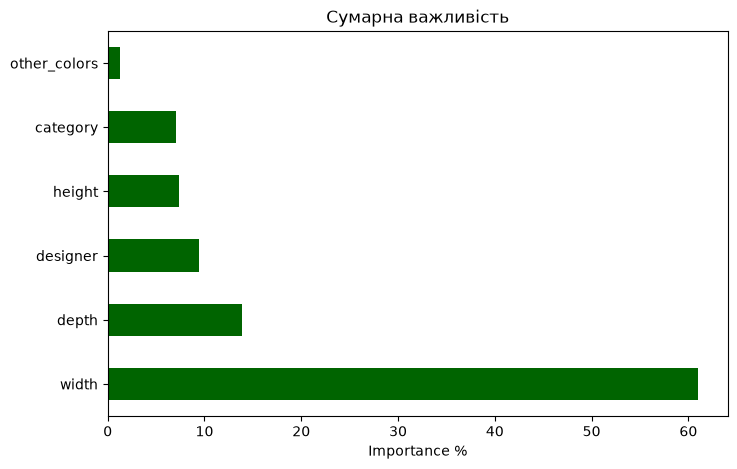

In [79]:
plt.figure(figsize=(8,5))
ax = grouped_importance_percent.plot(kind='barh', color='darkgreen')
plt.title('Сумарна важливість')
plt.xlabel('Importance %')
plt.ylabel('')

Ширина товару найсильніший фактор впливу на прогнозування ціни.

=============

Cross-Validation:

In [80]:
scores = cross_val_score(grid_search.best_estimator_ , X_train,  y_train, cv=KFold(n_splits=5, shuffle=True, random_state=42)).mean()
scores

np.float64(0.7868237619835338)

In [81]:
scores_fold = cross_val_score(grid_search.best_estimator_, X_train, y_train,cv=KFold(n_splits=5, shuffle=True, random_state=42))
scores_fold

array([0.76108969, 0.75509313, 0.7933665 , 0.81607765, 0.80849182])

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5')])

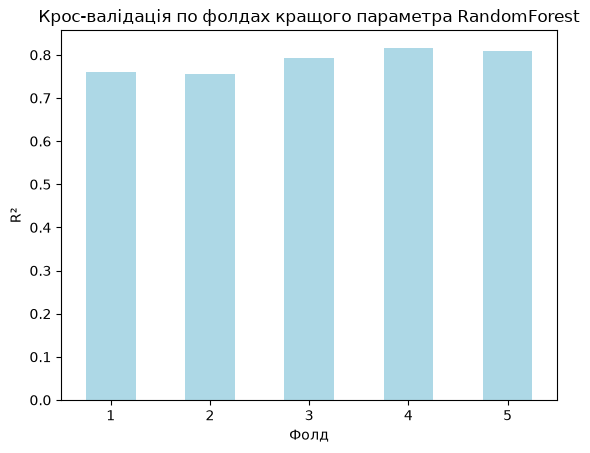

In [82]:
pd.Series(scores_fold, index=range(1,6)).plot(kind='bar', color='lightblue')
plt.title('Крос-валідація по фолдах кращого параметра RandomForest')
plt.ylabel('R²')
plt.xlabel('Фолд')
plt.xticks(rotation=0)

Графік вище підтверджує , що модель РандомФорест є стабільною.

===========================

Можливі методи покращення:

1) Деякі дизанери повторюються, наприклад  "Ehlén Johansson" та "Ehlén Johansson/IKEA of Sweden" . Можно спробуквати розділити всіх дизанерів окремо які повторюються.
2) Опрацювати колонку "short_description" . Упорядкувати дані та знайти інформацію за якою можно працювати.
3) GridSearchCV упирався в верхню межу. Можна спробувати розриширити сітку пошуку.